# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np


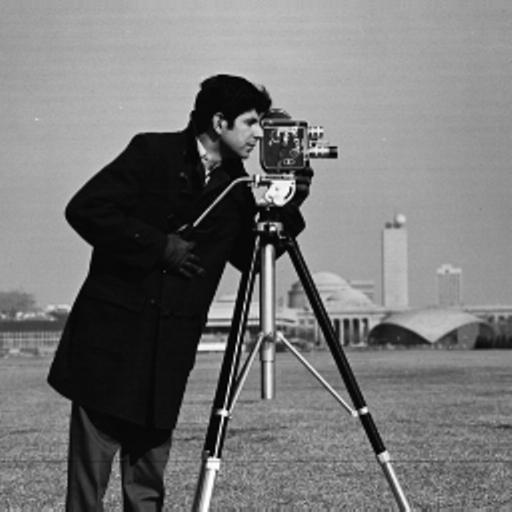

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg").convert("RGB")
img


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print(f"Original size: {width} x {height}")

# scaling factors
scale_x = 2
scale_y = 2


Original size: 512 x 512


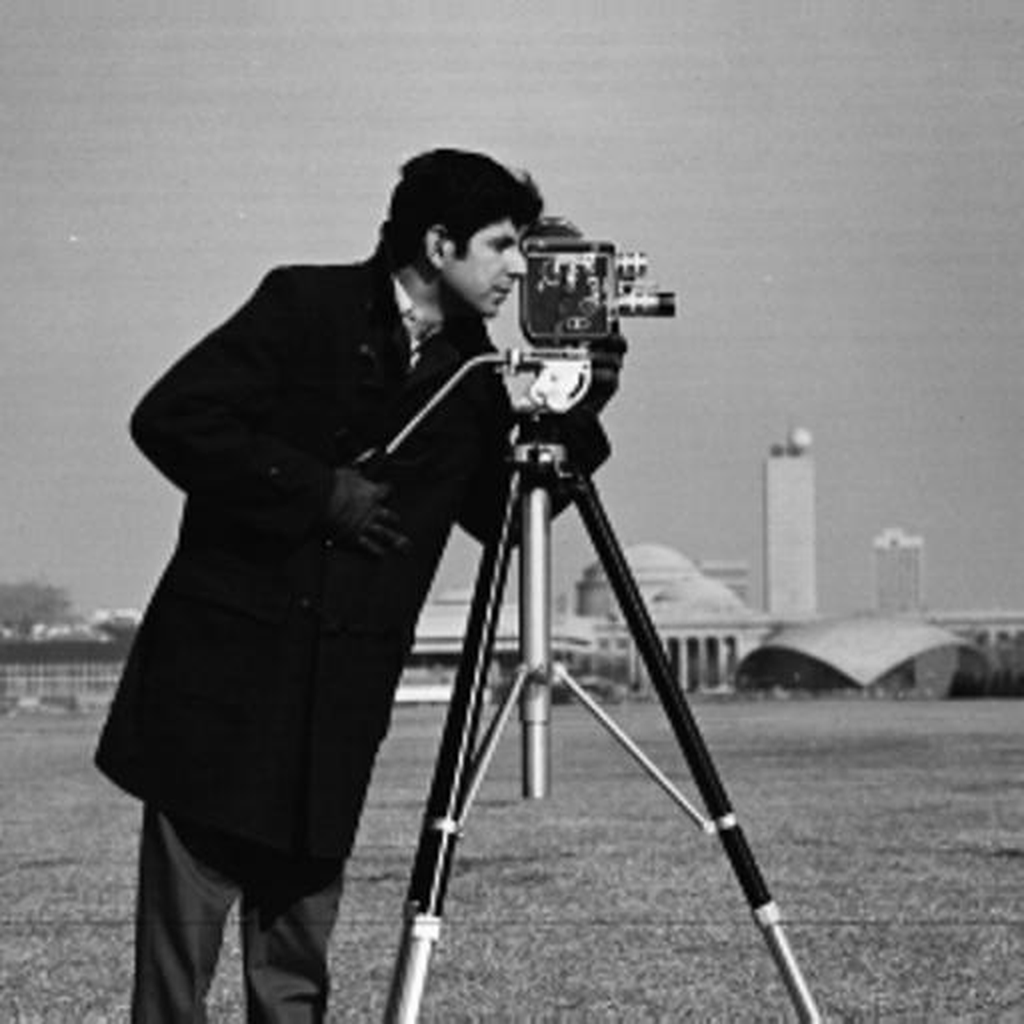

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * scale_x)
new_height = int(height * scale_y)

# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)
scaled_img


In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"Original size: {img.size}")
print(f"Scaled size:   {scaled_img.size}")


Original size: (512, 512)
Scaled size:   (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Non-uniform scale factors → stretch horizontally only
cx, cy = 2, 1


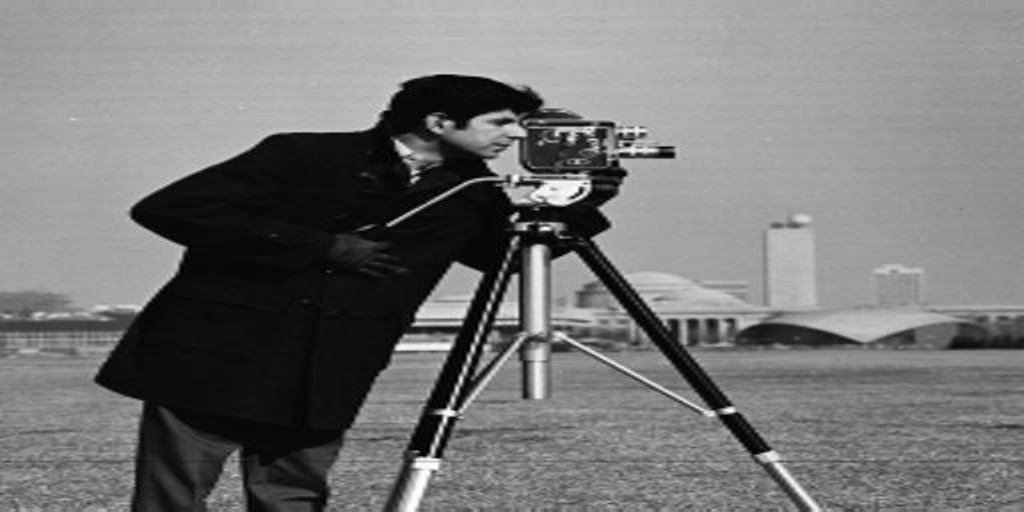

In [7]:
nonuniform_width  = int(width * cx)
nonuniform_height = int(height * cy)

nonuniform_scaled_img = img.resize((nonuniform_width, nonuniform_height), Image.LANCZOS)
nonuniform_scaled_img


In [8]:
nonuniform_scaled_img.save("task1_1b_nonuniform_scaled.jpg")
print(f"Original size:      {img.size}")
print(f"Non-uniform scaled: {nonuniform_scaled_img.size}")


Original size:      (512, 512)
Non-uniform scaled: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size:  (700, 700)


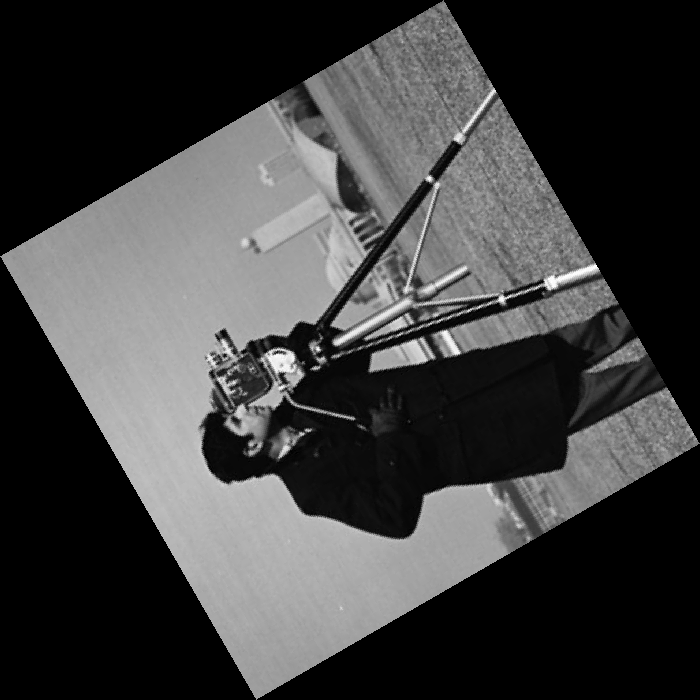

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")
print(f"Original size: {img.size}")
print(f"Rotated size:  {rotated_img.size}")
rotated_img


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print(f"Original size: {width} x {height}")


Original size: 512 x 512


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

# X-axis shear: shx slants columns sideways based on row position
shx, shy = shear_factor, 0

# Expand the canvas so the slanted content isn't cropped
new_width  = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)


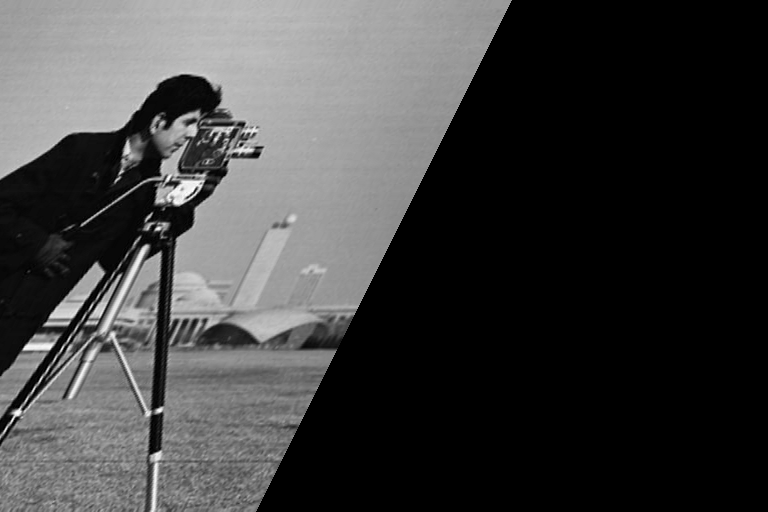

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
tx = -abs(shx) * height if shx < 0 else 0
ty = -abs(shy) * width  if shy < 0 else 0

sheared_img = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    (1, shx, tx, shy, 1, ty),
    resample=Image.BICUBIC,
    fillcolor=(0, 0, 0),
)
sheared_img


In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print(f"Original size: {img.size}")
print(f"Sheared size:  {sheared_img.size}")


Original size: (512, 512)
Sheared size:  (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

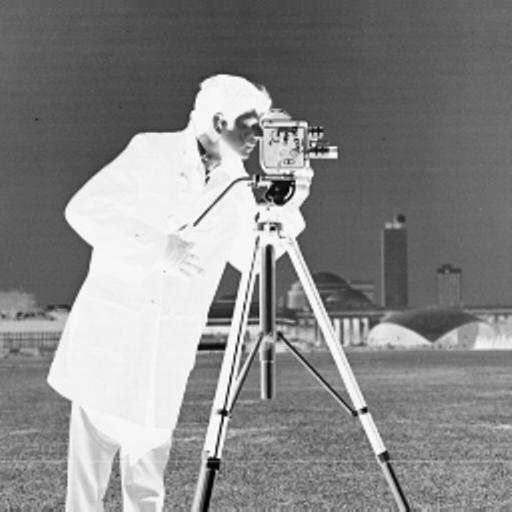

In [14]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_array = np.array(img)
negative_array = 255 - img_array
negative_img_np = Image.fromarray(negative_array.astype(np.uint8))
negative_img_np.save("task2_1_negative_numpy.jpg")
negative_img_np


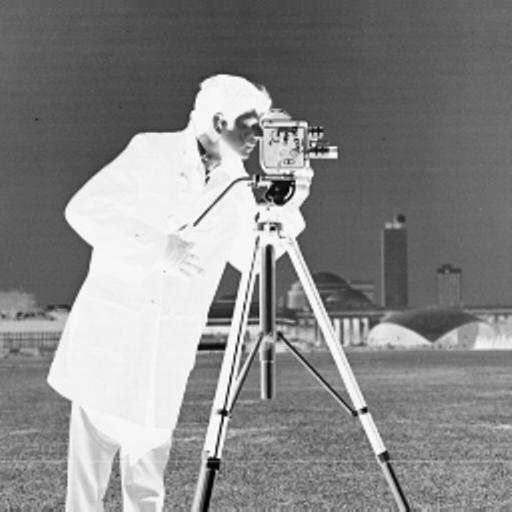

In [15]:
# Method 2: PIL's ImageOps
negative_img_ops = ImageOps.invert(img)
negative_img_ops.save("task2_1_negative_imageops.jpg")
negative_img_ops


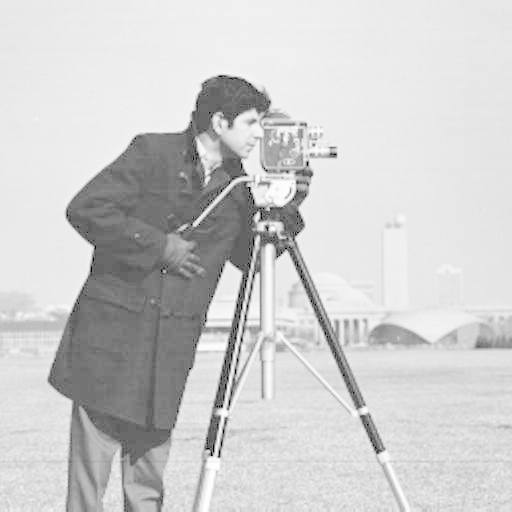

In [16]:
# ── 2. Log transformation ──────────────────────────
img_array = np.array(img).astype(np.float64)

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)
log_array = np.clip(log_array, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_array)
log_img.save("task2_2_log_transform.jpg")
log_img


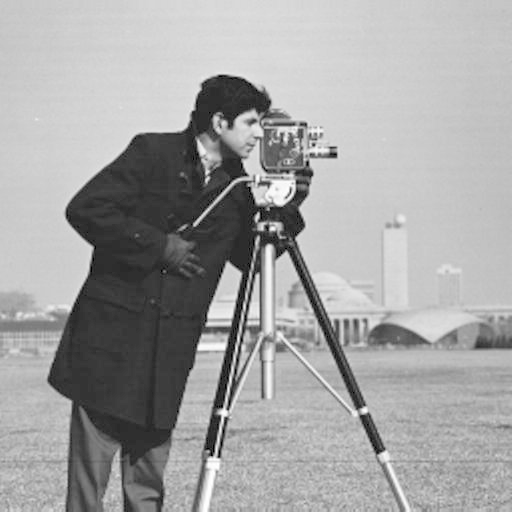

In [17]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5  # gamma < 1 brightens, gamma > 1 darkens — try 0.4, 1.5, 2.2

img_norm = np.array(img).astype(np.float64) / 255.0
gamma_array = np.power(img_norm, gamma)
gamma_array = np.clip(gamma_array * 255, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_array)
gamma_img.save("task2_3_gamma_correction.jpg")
gamma_img


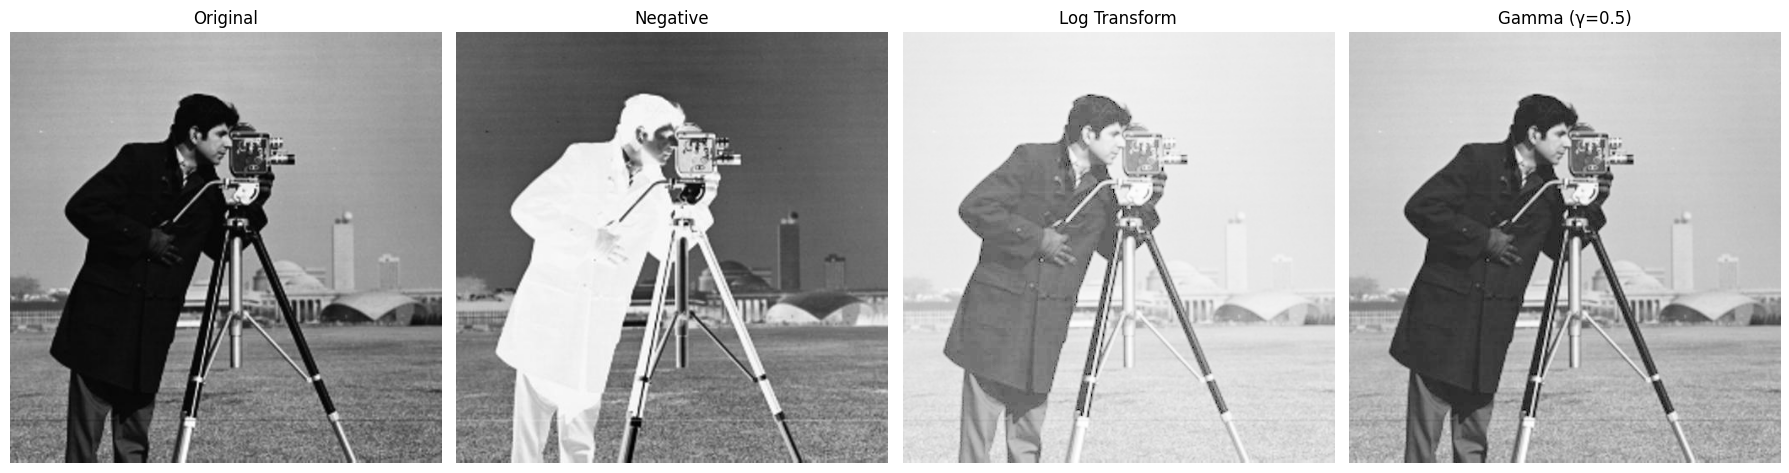

In [18]:
# Compare all intensity transformations side by side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ["Original", "Negative", "Log Transform", f"Gamma (γ={gamma})"]
images = [img, negative_img_ops, log_img, gamma_img]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig("task2_comparison.jpg", dpi=120)
plt.show()
